This script is intended to reproduce plots from Felice et. al. (2025) Diagnostic Tools for Evaluating Solvers for Stochastically Constrained Simulation Optimization Problems please ensure you have followed the download directions found here https://github.com/nicolefelice/stochastic_constraint_tools/blob/stoch_constraints/README.md before running. 

In [1]:
# Import the ProblemSolver class and other useful functions
from simopt.experiment_base import (
    ProblemSolver,
    post_normalize,
    plot_progress_curves,
    plot_solvability_cdfs,
    plot_feasibility,
    ProblemsSolvers,
    plot_terminal_progress,
    plot_feasibility_progress

)

In [2]:
from simopt.models.san import SANLongestPathStochastic
from simopt.solvers.fcsa import FCSA

In [3]:
# initialize problem
initial = (5,)*13 # starting mean for each arc
constraint_nodes = [6,8] #nodes with corresponding stochastic constraints
max_length_to_node = [5, 5] # max expected length to each constraint node
budget = 10000 # number of simmulation replications ran by solver
problem_factors = {"constraint_nodes": constraint_nodes,
                   "length_to_node_constraint": max_length_to_node,
                    "initial_solution": initial, 
                   "budget": budget
}
problem = SANLongestPathStochastic(fixed_factors=problem_factors)
problems = [problem]

In [4]:
# initialize solvers
rho_values = [0,.1,1,10,100]
solvers = []
for rho in rho_values:
    solver_factors =  {"search_direction": "FCSA",
               "normalize_grads": True,
               "report_all_solns": True,
               "crn_across_solns": False,
                "feas_const": float(rho),
}
    solver = FCSA(fixed_factors = solver_factors, name = f"FCSA_{rho}")
    solvers.append(solver)


In [5]:
#initialize experiment
myexperiment = ProblemsSolvers(solvers=solvers, problems=problems)

In [6]:
# Run a fixed number of macroreplications of the solver on the problem.
myexperiment.run(n_macroreps=10)

Running 10 macro-replications of FCSA_0 on SAN-2.
Running Solver FCSA_0 on Problem SAN-2.
Starting macroreplications in parallel
Finished running 10 macroreplications in 13.944 seconds.
File Name: FCSA_0_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56\FCSA_0_on_SAN-2.pickle
Running 10 macro-replications of FCSA_0.1 on SAN-2.
Running Solver FCSA_0.1 on Problem SAN-2.
Starting macroreplications in parallel
Finished running 10 macroreplications in 13.842 seconds.
File Name: FCSA_0.1_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56\FCSA_0.1_on_SAN-2.pickle
Running 10 macro-replications of FCSA_1 on SAN-2.
Running Solver FCSA_1 on Problem SAN-2.
Starting macroreplications in parallel
F

In [7]:
# Run a fixed number of postreplications at all recommended solutions.
myexperiment.post_replicate(n_postreps=100)

Post-processing FCSA_0 on SAN-2.
Setting up 100 postreplications for 10 macroreplications of FCSA_0 on SAN-2.
Starting postreplications in parallel
Finished running 10 postreplications in 14.478 seconds.
File Name: FCSA_0_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56\FCSA_0_on_SAN-2.pickle
Post-processing FCSA_0.1 on SAN-2.
Setting up 100 postreplications for 10 macroreplications of FCSA_0.1 on SAN-2.
Starting postreplications in parallel
Finished running 10 postreplications in 13.585 seconds.
File Name: FCSA_0.1_on_SAN-2.pickle
Folder Name: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56
File Path: C:\Users\nikki\GitHub\stochastic_constraint_tools\experiments\2026-04-08_12-39-56\FCSA_0.1_on_SAN-2.pickle
Post-processing FCSA_1 on SAN-2.
Setting up 100 postreplications for 10 macroreplications of F

In [8]:
# Find an optimal solution x* for normalization.
myexperiment.post_normalize(100)

Postnormalizing on Problem SAN-2.
Finding f(x*)...
	...using best postreplicated solution as proxy for x*.
fstar from postnormalization is... 17.870280968425533


[[<simopt.experiment_base.ProblemSolver object at 0x000001FE395E6A50>], [<simopt.experiment_base.ProblemSolver object at 0x000001FE343F5A90>], [<simopt.experiment_base.ProblemSolver object at 0x000001FE3958F750>], [<simopt.experiment_base.ProblemSolver object at 0x000001FE390FC510>], [<simopt.experiment_base.ProblemSolver object at 0x000001FE343C3100>]]


['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2026-04-08_12-39-56\\plots\\SOLVER_SET_on_SAN-2_terminal_violin_unnorm.png']

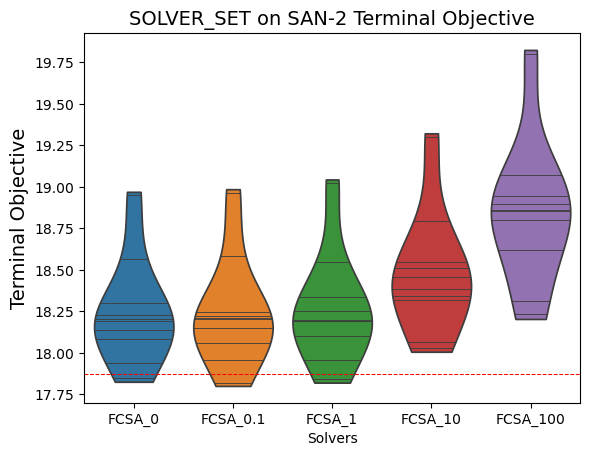

In [9]:
# Plot Figure 2
plot_experiments = []
for exp in myexperiment.experiments:
    plot_experiments.append(exp[0])
print(myexperiment.experiments)
# plot Fig 2 a terminal objective density violin plot for csa
plot_terminal_progress(plot_experiments, "violin", plot_optimal = True, normalize=False, save_as_pickle = True)

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2026-04-08_12-39-56\\plots\\SOLVER_SET_on_SAN-2_feasibility_violin_inf_norm_unnorm.png']

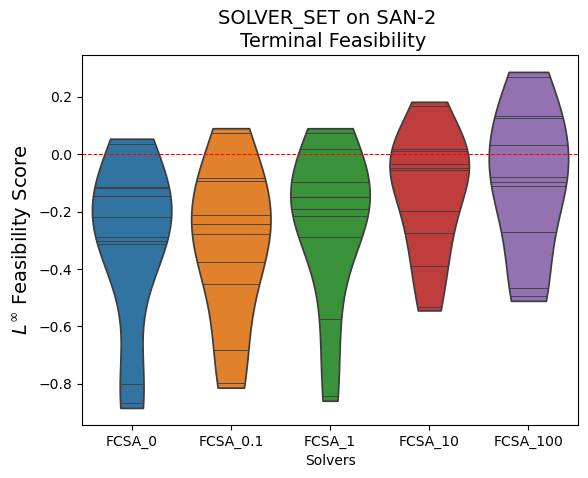

In [10]:
# plot Fig 2 b terminal objective density violin plot for csa
plot_feasibility(myexperiment.experiments, "violin",  all_in_one=True, two_sided=True, save_as_pickle=True)

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2026-04-08_12-39-56\\plots\\SOLVER_SET_on_SAN-2_all_prog_curves_unnorm.png']

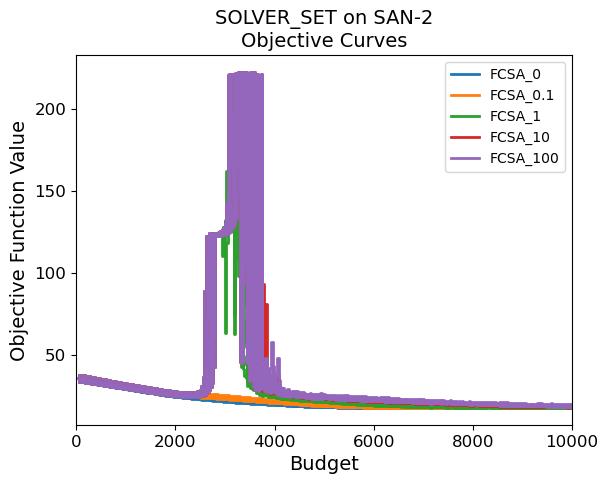

In [11]:
# plot Figure 3
# plot Fig 3 a csa objective progress
plot_progress_curves(plot_experiments, "all", normalize=False)

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2026-04-08_12-39-56\\plots\\SOLVER_SET_on_SAN-2_mean_prog_curve_unnorm.png']

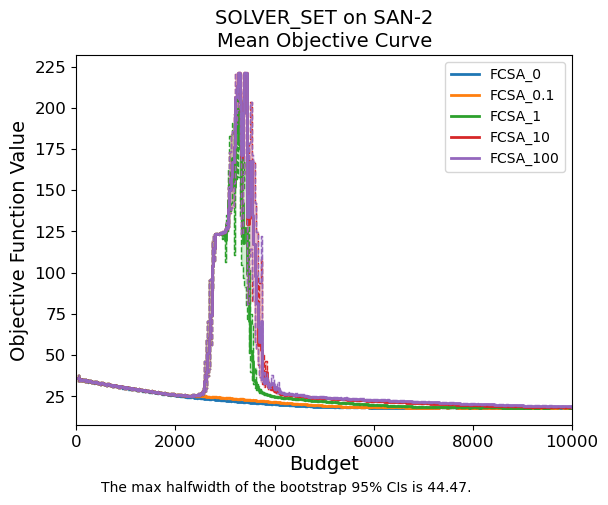

In [12]:
# plot Figure 3
# plot Fig 3 a csa objective progress
plot_progress_curves(plot_experiments, "mean", normalize=False)

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2026-04-08_12-39-56\\plots\\SOLVER_SET_on_SAN-2_all_prog_curves_unnorm (1).png']

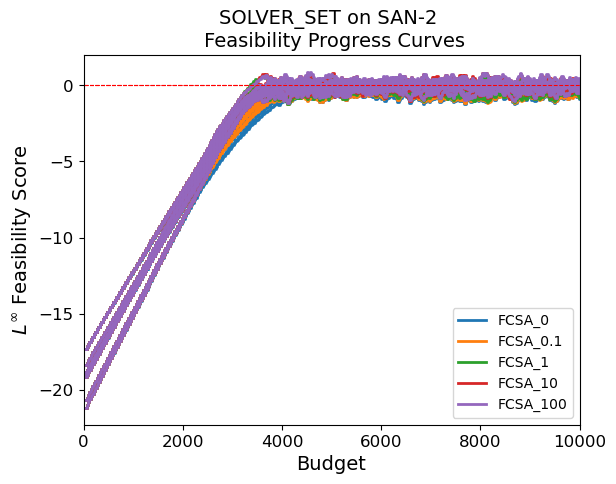

In [13]:
# plot Fig 3 a csa feasibility progress
plot_feasibility_progress(myexperiment.experiments, "all", print_max_hw=False)

['C:\\Users\\nikki\\GitHub\\stochastic_constraint_tools\\experiments\\2026-04-08_12-39-56\\plots\\SOLVER_SET_on_SAN-2_mean_prog_curve_unnorm (1).png']

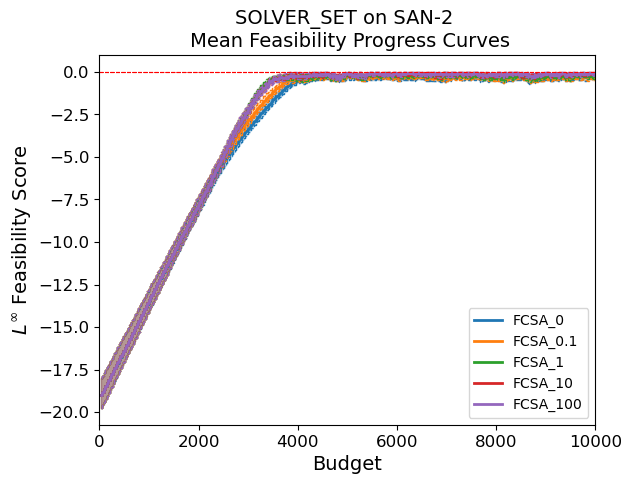

In [15]:
# plot Fig 3 a csa feasibility progress
plot_feasibility_progress(myexperiment.experiments, "mean", print_max_hw=False, two_sided=False)

In [ ]:
# plot Figure 5
plot_feasibility(myexperiment.experiments, plot_conf_ints = True, save_as_pickle = True)